In [85]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, KFold

In [86]:
# Generate random data for dogs and cats
np.random.seed(0)   # for reproducibility

In [87]:
# Dogs higher flappiness index lower whisker length
dogs_whisker_length = np.random.normal(loc=5, scale=1, size=10)           # loc refer to mean, scale refer to standard deviation
dogs_ear_flappiness_index = np.random.normal(loc=8, scale=1, size=10)

In [88]:
# Cats higher flappiness index lower whisker length
cats_whisker_length = np.random.normal(loc=8, scale=1, size=10)
cats_ear_flappiness_index = np.random.normal(loc=5, scale=1, size=10)

In [89]:
# Combine data
dogs_data = np.vstack((dogs_whisker_length, dogs_ear_flappiness_index)).T     # concatinate x and y 
cats_data = np.vstack((cats_whisker_length, cats_ear_flappiness_index)).T     # convert (2 * 10) into (10 * 2) 
data = np.vstack((dogs_data, cats_data))                                  # concat dogs and cat data                                  
labels = np.hstack((np.zeros(len(dogs_data)), np.ones(len(cats_data))))          # 0 - dogs,  # 1 - cats

In [90]:
labels                # creating labels for binary classification dataset

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1.])

In [91]:
X_train, X_test, y_train, y_test = train_test_split(data, labels, test_size=0.2, random_state=42)

# random_state fixes the randomness so that the train–test split is reproducible every time the code runs.

In [92]:
X_test

array([[6.76405235, 8.14404357],
       [7.81281615, 6.20237985],
       [6.54563433, 5.15634897],
       [5.40015721, 9.45427351]])

In [93]:
X_train

array([[ 4.89678115,  8.3130677 ],
       [ 4.02272212,  8.33367433],
       [ 8.6536186 ,  5.37816252],
       [ 7.2408932 ,  8.12167502],
       [ 9.53277921,  4.61267318],
       [ 8.04575852,  6.23029068],
       [ 7.25783498,  3.01920353],
       [ 5.97873798,  8.76103773],
       [ 5.4105985 ,  7.14590426],
       [ 9.46935877,  4.69769725],
       [ 6.86755799,  8.44386323],
       [ 8.8644362 ,  4.11221425],
       [ 4.84864279,  7.79484174],
       [ 5.44701018,  5.15494743],
       [10.26975462,  4.65208785],
       [ 5.95008842,  9.49407907]])

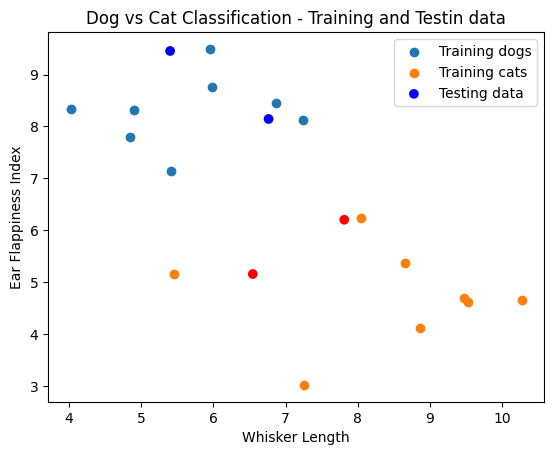

In [94]:
# Plot the training and testing data points

plt.scatter(X_train[y_train == 0][:, 0], X_train[y_train == 0][:, 1], label = 'Training dogs')
plt.scatter(X_train[y_train == 1][:, 0], X_train[y_train == 1][:, 1], label = 'Training cats')

plt.scatter(X_test[:, 0], X_test[:, 1], c = y_test, cmap='bwr', label='Testing data')
plt.xlabel('Whisker Length')
plt.ylabel('Ear Flappiness Index')
plt.legend()
plt.title('Dog vs Cat Classification - Training and Testin data')
plt.show()

In [95]:
# Implementing random linear classifier algorithm

def random_linear_classifier(data_dogs, data_cats, k, d):  # k = choices, d = no of features here 2
    best_error = float('inf')
    best_theta = None
    best_theta0 = None

    for _ in range(k):
        theta = np.random.normal(size=d)
        theta0 = np.random.normal()

        error = compute_error(data_dogs, data_cats, theta, theta0)

        if error < best_error:
            best_error = error
            best_theta = theta
            best_theta0 = theta0
    return best_theta, best_theta0, error

def compute_error(data_dogs, data_cats, theta, theta0):
    error = 0
    for x_dog in data_dogs:
        if np.dot(theta, x_dog) + theta0 <= 0:
            error +=1
    for x_cat in data_cats:
        if np.dot(theta, x_cat) + theta0 > 0:
            error +=1
    return error

In [96]:
# Run random linear classifire algorithm
k = 500  # no of iteration 
d = 2     # no of features

best_theta_train, best_theta0_train, train_error = random_linear_classifier(
    X_train[y_train == 0],
    X_train[y_train == 1],
    k,
    d
)

In [97]:
x_vals_train = np.linspace(2, 10, 100)
y_vals_train = (-best_theta_train[0] / best_theta_train[1]) * x_vals_train - (best_theta0_train / best_theta_train[1])  # (m * x)

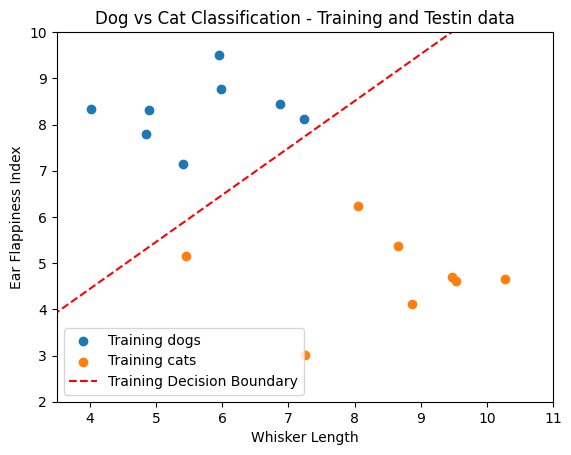

In [98]:
plt.scatter(X_train[y_train == 0][:, 0], X_train[y_train == 0][:, 1], label = 'Training dogs')
plt.scatter(X_train[y_train == 1][:, 0], X_train[y_train == 1][:, 1], label = 'Training cats')
plt.plot(x_vals_train, y_vals_train, color='red', linestyle='--', label= 'Training Decision Boundary')
# set same limit for the x and y axis
plt.xlim([3.5, 11])
plt.ylim([2, 10])
plt.xlabel('Whisker Length')
plt.ylabel('Ear Flappiness Index')
plt.legend()
plt.title('Dog vs Cat Classification - Training and Testin data')
plt.show()

In [99]:
print(f"Training error:  {train_error}")

Training error:  8


In [100]:
# to see the performance of the classifier


# compute testing error
test_error = compute_error(X_test[y_test==0], X_test[y_test==1], best_theta_train, best_theta0_train)

print(f"Training error:  {test_error}")

Training error:  0


In [101]:
# Define functions for k-fold cross validation

def cross_validate(data_dogs, data_cats, k_values, d, n_splits=5):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    avg_errors = []

    for k in k_values:
        errors = []

        for train_index, val_index in kf.split(data_dogs):
            X_train_fold = np.vstack((data_dogs[train_index], data_cats[train_index]))
            y_train_fold = np.hstack((np.zeros(len(train_index)), np.ones(len(train_index))))
            X_val_fold = np.vstack((data_dogs[val_index], data_cats[val_index]))
            y_val_fold = np.hstack((np.zeros(len(val_index)), np.ones(len(val_index))))

            best_theta_fold, best_theta0_fold, error= random_linear_classifier(X_train_fold[y_train_fold == 0], X_train_fold[y_train_fold == 1], k, d)

            error = compute_error(X_val_fold[y_val_fold == 0], X_val_fold[y_val_fold == 1], best_theta_fold, best_theta0_fold)
            
        errors.append(error)
        avg_errors.append(np.mean(errors))
    
    best_k = k_values[np.argmin(avg_errors)]

    return best_k

# define k values to try
k_values = [1, 10, 50, 100, 200, 350]

best_k = cross_validate(dogs_data, cats_data, k_values, d=2)

print(f"Best value of k:  {best_k}")

Best value of k:  10


In [102]:
# Run random linear classifier algorithm on training data

k = best_k
d = 2

best_theta_fold, best_theta0_fold, error= random_linear_classifier(X_train[y_train == 0], X_train[y_train == 1], k, d)

In [103]:
x_vals_train = np.linspace(2, 10, 100)
y_vals_train = (-best_theta_train[0] / best_theta_train[1]) * x_vals_train - (best_theta0_train / best_theta_train[1])  # (m * x)

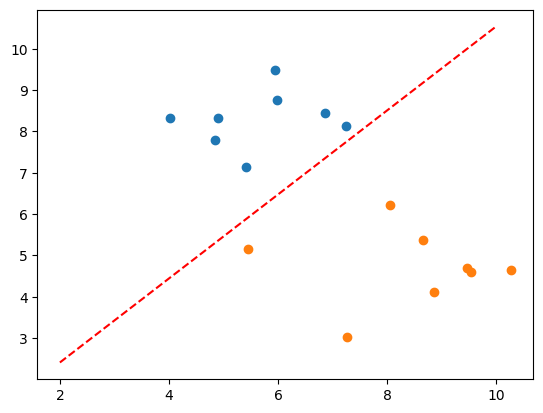

In [104]:
plt.scatter(X_train[y_train == 0][:, 0], X_train[y_train == 0][:, 1], label = 'Training dogs')
plt.scatter(X_train[y_train == 1][:, 0], X_train[y_train == 1][:, 1], label = 'Training cats')
plt.plot(x_vals_train, y_vals_train, color='red', linestyle='--', label= 'Training Decision Boundary')

plt.show()

In [105]:
print(f"Training error:  {train_error}")

Training error:  8


In [106]:
# to see the performance of the classifier


# compute testing error
test_error = compute_error(X_test[y_test==0], X_test[y_test==1], best_theta_train, best_theta0_train)

print(f"Training error:  {test_error}")

Training error:  0
